In [5]:
!python3 borough_complaints.py -i nyc_311_2024.csv -s 2024-01-01 -e 2024-02-29 -o jan_feb_counts_sorted.csv


In [6]:
import csv
from collections import Counter

by_type_total = Counter()

with open("jan_feb_counts_sorted.csv", "r") as f:
    rows = csv.DictReader(f)
    for row in rows:
        ctype = (row.get("complaint type", "")).strip()
        count = int((row.get("count", "0").strip()))

        if ctype:
            by_type_total[ctype] += count

top_complaint = by_type_total.most_common(1)[0][0] #returns most frequent complaint
print("Top complaint", top_complaint)
print("Top 5 complaint", by_type_total.most_common(5))

Top complaint heat/hot water
Top 5 complaint [('heat/hot water', 81640), ('illegal parking', 79916), ('noise - residential', 43602), ('blocked driveway', 28608), ('unsanitary condition', 19208)]


In [7]:
!python3 borough_complaints.py -i nyc_311_2024.csv -s 2024-06-01 -e 2024-07-31 -o jun_jul_counts_sorted.csv



In [9]:
import csv
from collections import Counter

by_type_total = Counter()

with open("jun_jul_counts_sorted.csv", "r") as f:
    rows = csv.DictReader(f)
    for row in rows:
        ctype = (row.get("complaint type", "")).strip()
        count = int((row.get("count", "0").strip()))

        if ctype:
            by_type_total[ctype] += count

top_complaint = by_type_total.most_common(1)[0][0] #returns most frequent complaint
print("Top complaint", top_complaint)
print("Top 5 complaint", by_type_total.most_common(5))

Top complaint illegal parking
Top 5 complaint [('illegal parking', 86238), ('noise - residential', 58196), ('noise - street/sidewalk', 47320), ('blocked driveway', 27193), ('water system', 21653)]


In [2]:
import csv
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict

Starting analysis... This may take a few minutes.
Processed 60 days of data


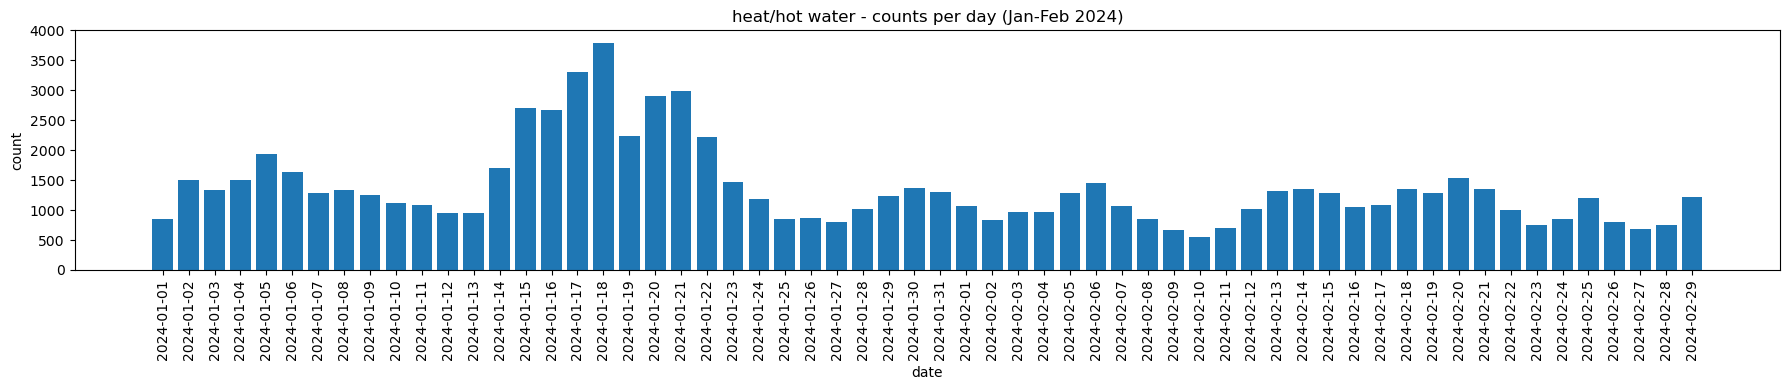

Plot completed!


In [22]:
import matplotlib.pyplot as plt
from datetime import datetime
import csv
import sys
import traceback

CREATE_COL = "Created Date"
COMPLAINT_COL = "Complaint Type"

top_complaint = "heat/hot water"

def parse_dt(s):
    if not s:
        return None 
    try: 
        return datetime.strptime(s, "%m/%d/%Y %I:%M:%S %p")
    except ValueError:
        pass
    return None

start_jf = datetime(2024,1,1)
end_jf = datetime(2024,3,1) #exclusive

def analyze_daily_complaints(file_path, complaint, start_date, end_date):
    daily = {}
    with open(file_path, "r") as f:
        r = csv.DictReader(f)
        for row in r:
            dt = parse_dt(row.get(CREATE_COL, ""))
            if dt is not None and not (start_date <= dt < end_date):
                continue 
            if row.get(COMPLAINT_COL, "").strip().lower() != complaint.lower():
                continue
            daily[dt.date()] = daily.get(dt.date(), 0) + 1
    return daily

try:
    print("Starting analysis... This may take a few minutes.")
    jf_daily = analyze_daily_complaints("nyc_311_2024.csv", top_complaint, start_jf, end_jf)
    print(f"Processed {len(jf_daily)} days of data")
    
    dates = sorted(jf_daily.keys())
    counts = [jf_daily[d] for d in dates]
    labels = [d.isoformat() for d in dates]

    #building plot 
    plt.figure(figsize=(18,4))
    plt.bar(labels, counts)
    plt.title(f"{top_complaint} - counts per day (Jan-Feb 2024)")
    plt.xlabel("date"); plt.ylabel("count")
    plt.xticks(rotation=90)
    plt.ylim([0,4000])
    plt.tight_layout(); plt.show()
    
    print("Plot completed!")
    
except Exception as e:
    print("ERROR:", e)
    traceback.print_exc()
    

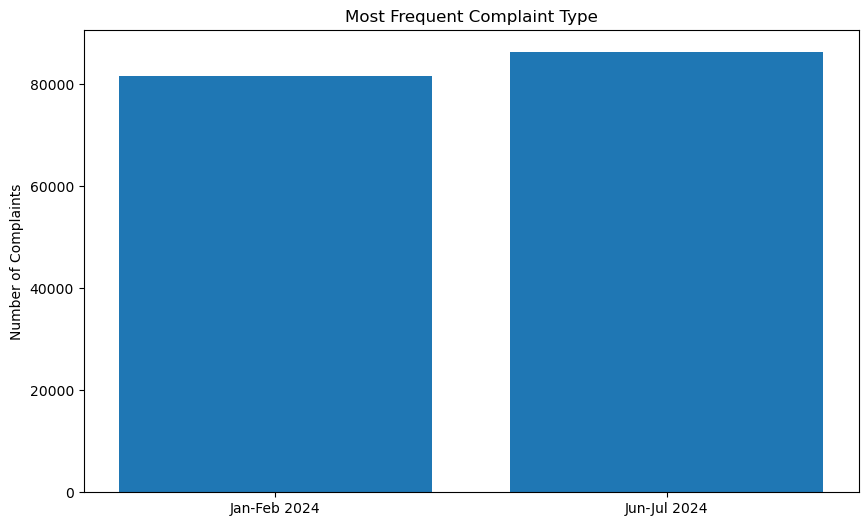

Chart should be displayed above!


In [19]:
# SIMPLE VERSION - Use your existing data
import matplotlib.pyplot as plt

jan_feb_count = 81640  # Your heat/hot water count
jun_jul_count = 86238  # Your illegal parking count

plt.figure(figsize=(10, 6))
plt.bar(['Jan-Feb 2024', 'Jun-Jul 2024'], [jan_feb_count, jun_jul_count])
plt.ylabel('Number of Complaints')
plt.title('Most Frequent Complaint Type')
plt.show()

print("Chart should be displayed above!")

totals for heat/hot water
Jan-Feb: 81641
Jun-Jul: 6890


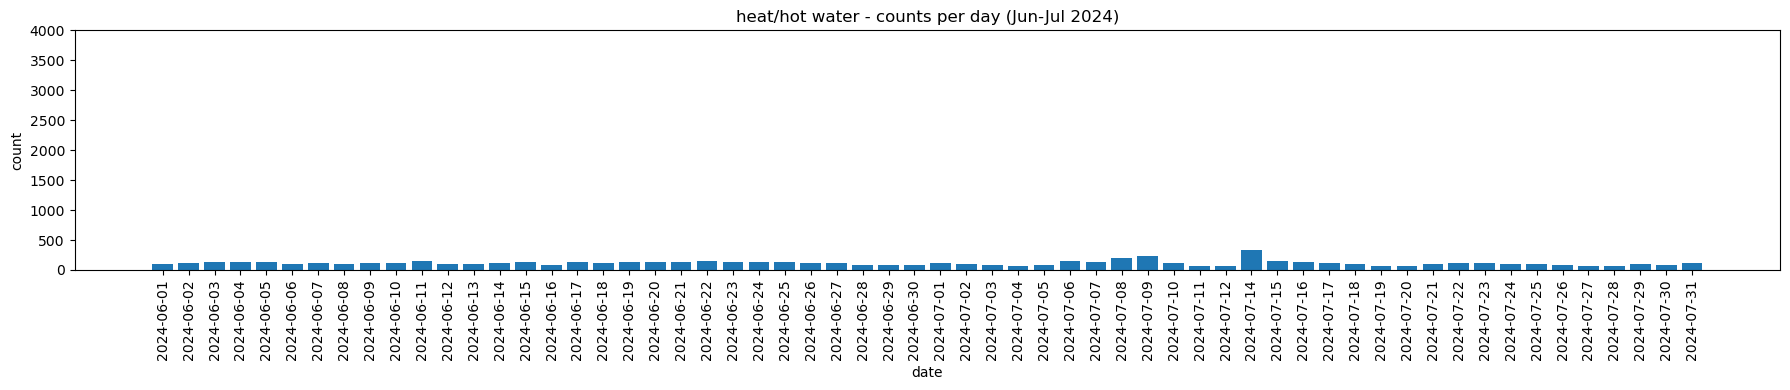

In [24]:
start_jf = datetime(2024,6,1)
end_jf = datetime(2024,8,1) #exclusive
jj_daily = analyze_daily_complaints("nyc_311_2024.csv", top_complaint, start_jf, end_jf)

print("totals for", top_complaint)
print("Jan-Feb:", sum(jf_daily.values()))
print("Jun-Jul:", sum(jj_daily.values()))

dates = sorted(jj_daily.keys())
counts = [jj_daily[d] for d in dates]
labels = [d.isoformat() for d in dates]

plt.figure(figsize=(18,4))
plt.bar(labels, counts)
plt.title(f"{top_complaint} - counts per day (Jun-Jul 2024)")
plt.xlabel("date"); plt.ylabel("count")
plt.xticks(rotation=90)
plt.ylim([0,4000])
plt.tight_layout(); plt.show()